<span style="text-align: center; color:#009999;">

# [LGBIO2050] - Medical Imaging
## *Challenge 1 - Histogram Equalization*
</span>

### Professors :   
- Prof. G. Kerckhofs  
- Prof. J. Lee
- Prof. B. Macq
- Prof. G. Duchêne
    
### Teaching assistants : 
- Pauline Hermans (pauline.hermans@uclouvain.be)
- Nicolas Delinte (nicolas.delinte@uclouvain.be)
- Simon Francois (simon.b.francois@uclouvain.be)

**2026-2027**

<span style="color:#009999;">

## 1. Guidelines and Deliverables
</span>

- This assignment is due on **14th October 2026**.
- The jupyter notebook containing the code and **detailed answers** to the questions must be delivered in an archive (.zip folder) on Moodle, with *"Markdown cells"* containing the answer to the questions and *"Code cells"* containing the code you implemented. The answers have to be written in English.
- This work must comply with the **EPL AI Guidelines** (available on Moodle) concerning the responsible use of AI in student work. Copying code or answers from other groups or from the internet is strictly prohibited. **Any source used for inspiration must be clearly acknowledged and referenced.**
- At the end of the semester, an **individual evaluation** will allow you to demonstrate that you have a good understanding of the challenge, both in terms of the code you have written and the answers to the reflection questions. Make sure that **all group members are familiar with each challenge and understand how it works**.
- The **presentation and overall formatting of your notebook** will also be taken into account in the assessment. Make sure to **write clean, efficient, well-structured code and comment it** appropriately to make it easy to understand. Your outputs and figures should also be clear and well-presented (do not forget titles, legends, etc. where appropriate). Pay particular attention to your answers to the questions as well. **Structure your explanations clearly** and use titles, subtitles, figures, and other relevant elements to make your **answers clear and precise**.  

<span style="color:#009999;">

## 2. Context and objective
</span>

When dealing with in vivo medical image acquisition, it happens that images contain significant amount of details which are not visually perceptible. 
One reason for this may be that these images are poorly contrasted, i.e., they have a poor dynamic range in their 
pixel intensities. In such situation, applying a transformation to the image that will stretch its dynamic range is 
often desirable.<br>


The normalised histogram of a gray level image is defined by the following equation:
 
$$ p(k)=\frac{n_{k}}{N}$$

where $n_{k}$  is the the number of pixels with gray level $k$ and $N$ is the total number of 
pixels. $p(k)$ can be interpreted as the probability of occurrence of gray level $k$. A plot of $n_{k}$ versus $k$ is known as a histogram.

The [cumulative distribution function](https://en.wikipedia.org/wiki/Cumulative_distribution_function) ($cdf$) of grayscale values in an image is then defined as
$$cdf(k)=\sum_{j=0}^{k} p(j)$$
Gray level transformations applied to the histogram are among the simplest of image enhancement techniques. However, such transforms have a wide range of applications despite their simplicity.<br>


Histogram Equalization (HE) is the transformation of the histogram denoted by $T$ :

$$ T(k)= cdf(k) $$


<span style="color:#009999;">

## 3. Data import
</span>

In this challenge, you will learn how to easily adjust the contrast of a medical image in order to reveal unvisible detailed. For this challenge, we will use three images, a **X-ray radiography** of a chest and another one of the knee (this modality is detailed in part 3.1 of the course), and a **CT image** of a skull. X-rays radiography uses electromagnetic radiation that can penetrate the body to varying degrees depending on the density of the tissues they encounter. It is commonly used to observe bones (e.g., fractures) and the thoracic area (e.g. pneumonia) as this modality provides a good contrast for hard tissues and for the air-filled lung spaces.

<div class="alert alert-info">

**QUESTION 1**

In the following cell, import and display the images: the chest and knee radiographs and the skull image (chest.png, knee.jpeg & skull.png).  

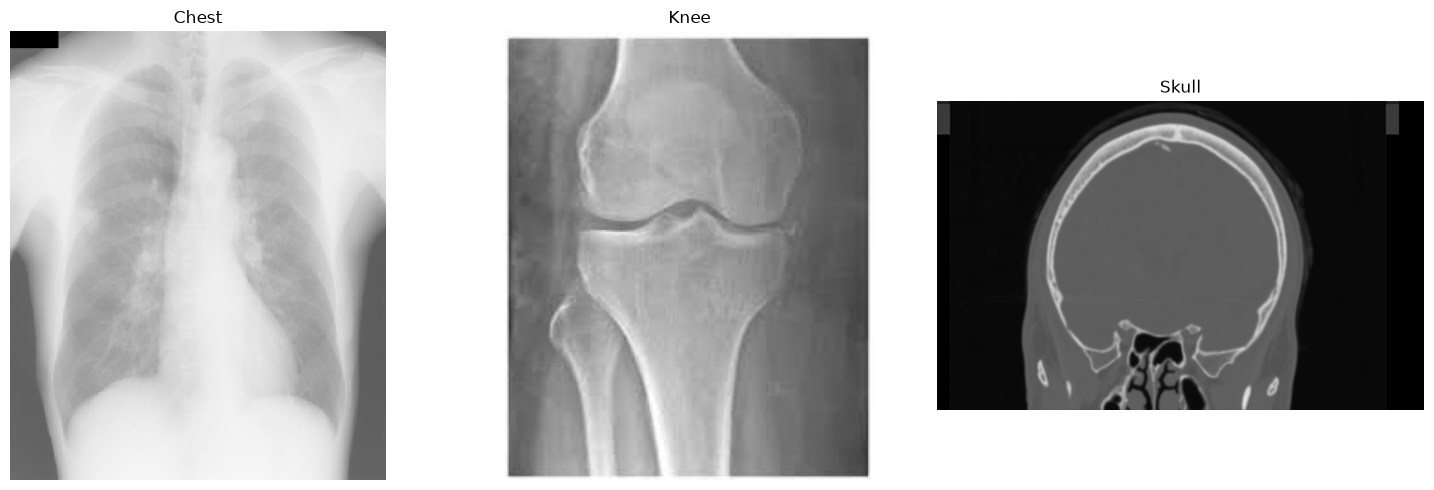

In [ ]:
from skimage.io import imread
from skimage.color import rgb2gray
import numpy as np
import matplotlib.pyplot as plt

#img1 = imread("./original_images/chest.png")    METODO STANDARD PER CARICARE E VISUALIZZARE L'IMMAGINE
#plt.imshow(img1)
#plt.show()

img1 = imread("./original_images/chest.png")
img2 = imread("./original_images/knee.jpeg")
img3 = imread("./original_images/skull.png")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img1)
axes[0].set_title("Chest")
axes[0].axis("off")

axes[1].imshow(img2)
axes[1].set_title("Knee")
axes[1].axis("off")

axes[2].imshow(img3)
axes[2].set_title("Skull")
axes[2].axis("off")

plt.tight_layout()
plt.show()





<span style="color:#009999;">

## 4. Histogram Equalization implementation
</span>

<div class="alert alert-info">

**QUESTION 2**

Implement, by yourself, the Histogram Equalization method. 

You are not allowed to use implemented version of the code (openCV, Skimage, PIL,...). The implementation can be achieved using only Numpy. Show your results on all three images, as well as their histograms and cumulative distribution functions (*cdf*), and comment them.

Chest shape: (347, 291, 3)
Knee shape: (246, 204, 3)
Skull shape: (2012, 3170, 3)


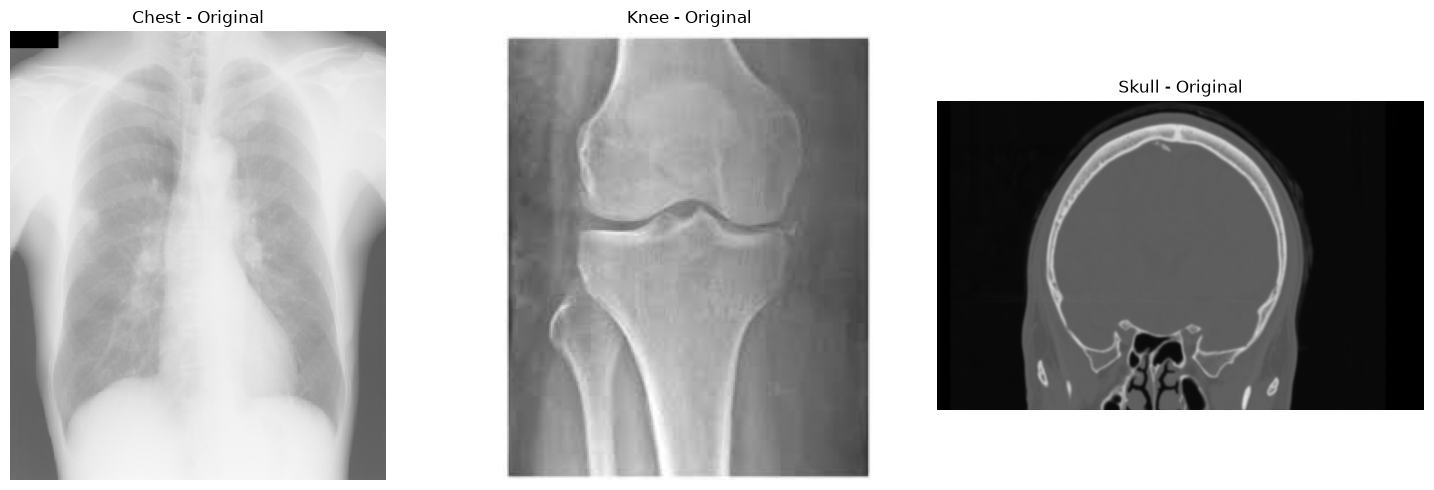

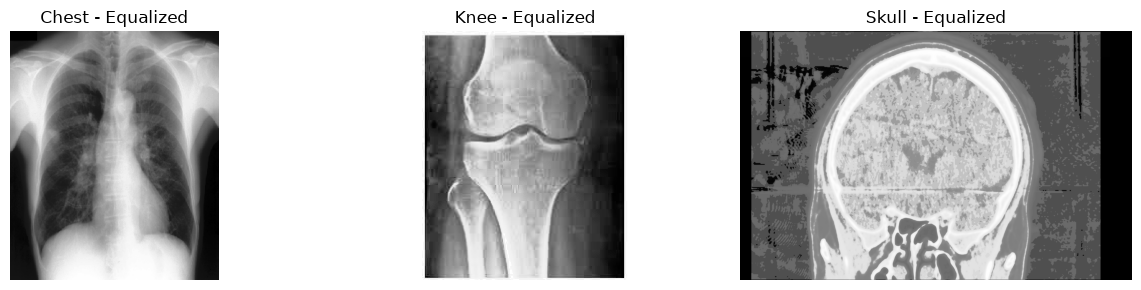

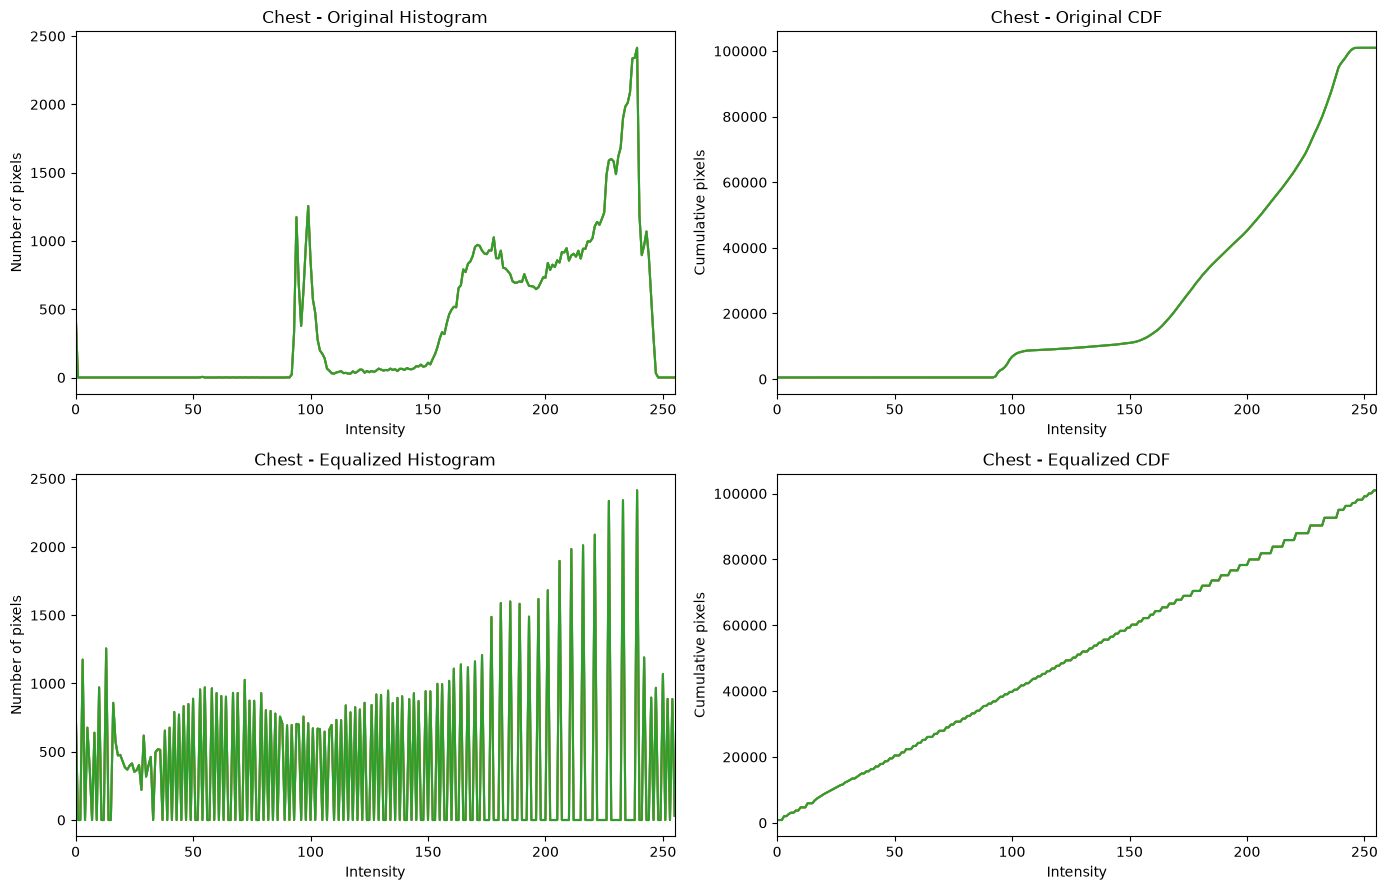

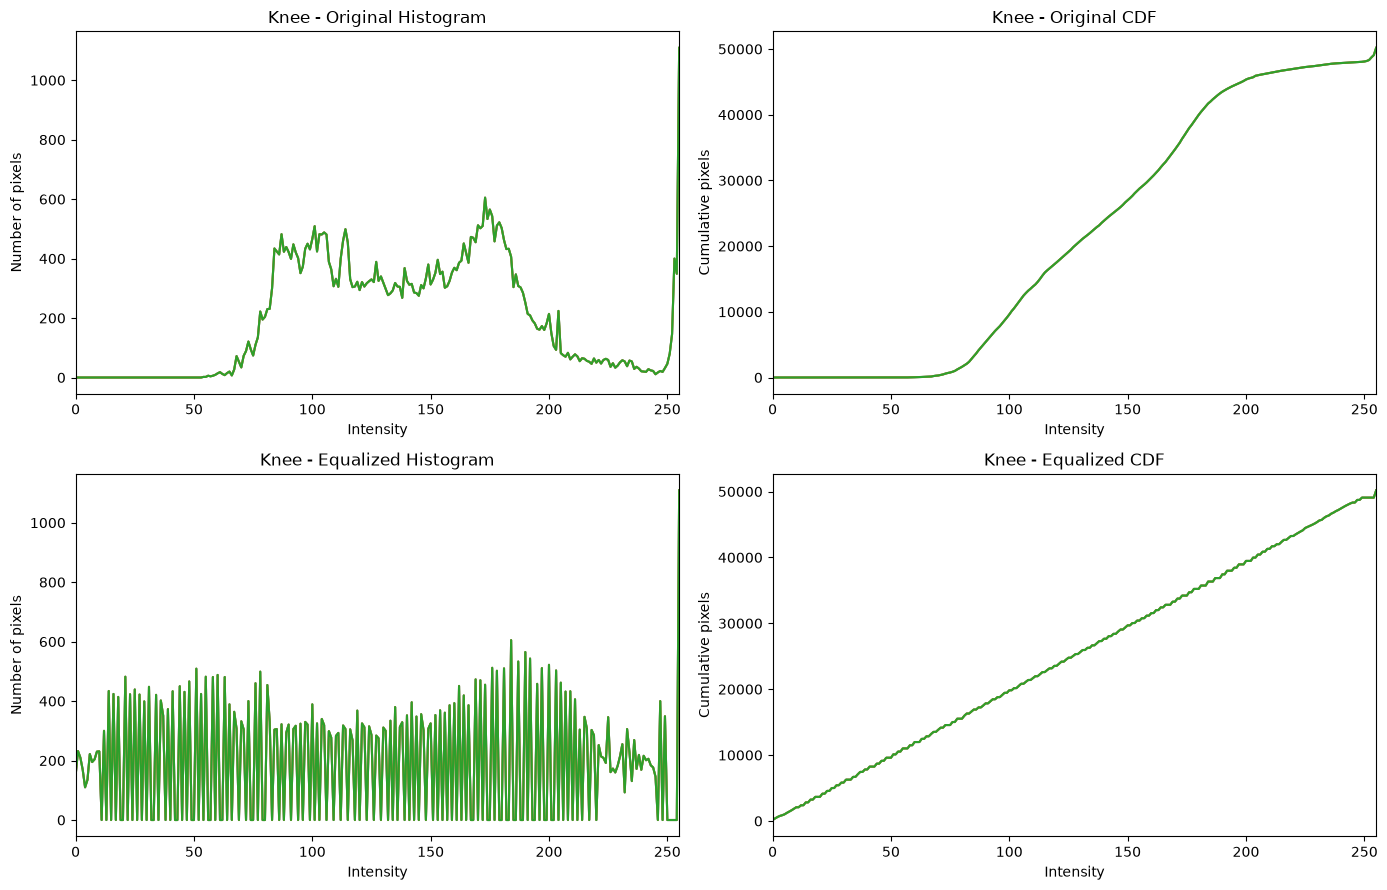

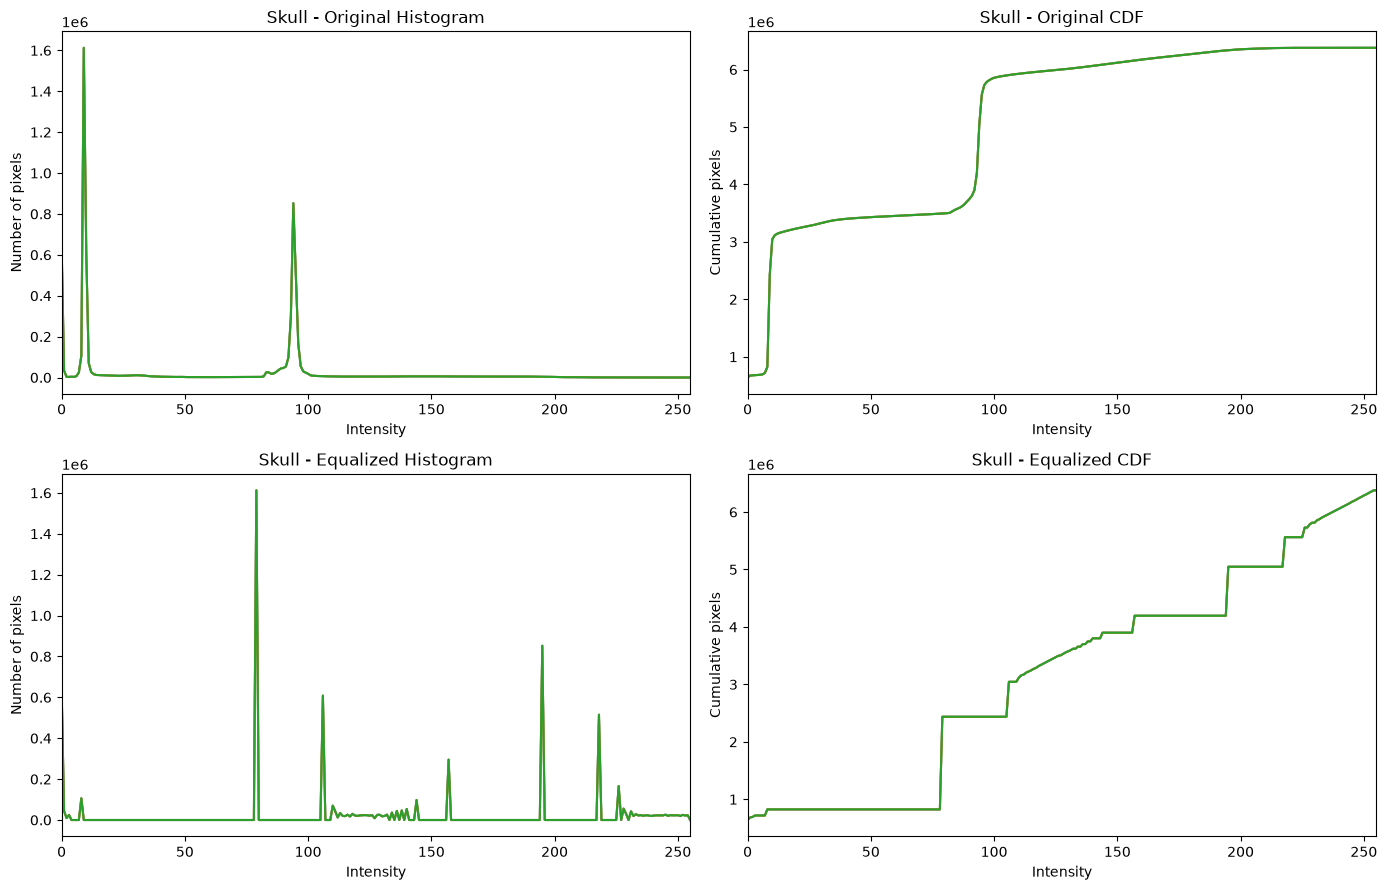

In [ ]:
# Histogram Equalization implementation

#img1_gray = rgb2gray(img1)
#plt.imshow(img1_gray, cmap="gray")
#plt.show()

#img2_gray = rgb2gray(img2)
#plt.imshow(img2_gray, cmap="gray")
#plt.show()

#print(img3.shape) # mi dice la dimensione dell'immagine
#from skimage.color import rgba2rgb # converte l'immagine da 4D a 3D)

#plt.imshow(img3, cmap="gray")
#plt.show()

def histeq():

    return 0

#-----------
from skimage.io import imread
import numpy as np
import matplotlib.pyplot as plt

# Conversione di qualsiasi immagine in RGB

def to_rgb(img):

    # Immagine grayscale: H x W
    if img.ndim == 2:
        img = np.stack((img, img, img), axis=-1)

    # Immagine RGBA: H x W x 4
    elif img.ndim == 3 and img.shape[2] == 4:
        img = img[:, :, :3]

    # Se l'immagine è float nel range 0-1,
    # la porto nel range 0-255
    if img.max() <= 1:
        img = img * 255

    return img.astype(np.uint8)


# Histogram Equalization di UN singolo canale
def histeq_channel(channel):

    # Istogramma: 256 livelli di intensità
    histogram = np.bincount(
        channel.flatten(),
        minlength=256
    )

    # CDF
    cdf = np.cumsum(histogram)

    # Primo valore della CDF diverso da zero
    cdf_min = cdf[cdf > 0][0]

    # Normalizzazione della CDF tra 0 e 255
    cdf_normalized = (
        (cdf - cdf_min) /
        (channel.size - cdf_min) * 255
    )

    cdf_normalized = np.clip(
        cdf_normalized,
        0,
        255
    )

    # Utilizzo della CDF come Look-Up Table
    channel_equalized = cdf_normalized[channel]

    return channel_equalized.astype(np.uint8), histogram, cdf


# Histogram Equalization RGB
def histeq(img):
    img = to_rgb(img)
    equalized = np.zeros_like(img)
    histograms = []
    cdfs = []

    # Equalizzazione indipendente di R, G e B
    for channel in range(3):

        eq_channel, histogram, cdf = histeq_channel(
            img[:, :, channel]
        )

        equalized[:, :, channel] = eq_channel

        histograms.append(histogram)
        cdfs.append(cdf)

    return equalized, histograms, cdfs


# Funzione per calcolare histogram e CDF RGB

def get_hist_cdf(img):
    img = to_rgb(img)
    histograms = []
    cdfs = []

    for channel in range(3):

        histogram = np.bincount(
            img[:, :, channel].flatten(),
            minlength=256
        )

        cdf = np.cumsum(histogram)

        histograms.append(histogram)
        cdfs.append(cdf)

    return histograms, cdfs

# Caricamento delle immagini
img1 = imread("./original_images/chest.png")
img2 = imread("./original_images/knee.jpeg")
img3 = imread("./original_images/skull.png")

# Conversione in RGB
img1 = to_rgb(img1)
img2 = to_rgb(img2)
img3 = to_rgb(img3)

# Controllo dimensioni
print("Chest shape:", img1.shape)
print("Knee shape:", img2.shape)
print("Skull shape:", img3.shape)

# Histogram Equalization
eq1, hist_eq1, cdf_eq1 = histeq(img1)
eq2, hist_eq2, cdf_eq2 = histeq(img2)
eq3, hist_eq3, cdf_eq3 = histeq(img3)

# Visualizzazione delle 3 immagini originali
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img1)
axes[0].set_title("Chest - Original")
axes[0].axis("off")

axes[1].imshow(img2)
axes[1].set_title("Knee - Original")
axes[1].axis("off")

axes[2].imshow(img3)
axes[2].set_title("Skull - Original")
axes[2].axis("off")

plt.tight_layout()
plt.show()

# Visualizzazione delle 3 immagini equalizzate
fig, axes = plt.subplots(1, 3, figsize=(13, 3))

axes[0].imshow(eq1)
axes[0].set_title("Chest - Equalized")
axes[0].axis("off")

axes[1].imshow(eq2)
axes[1].set_title("Knee - Equalized")
axes[1].axis("off")

axes[2].imshow(eq3)
axes[2].set_title("Skull - Equalized")
axes[2].axis("off")

plt.tight_layout()
plt.show()

# Funzione per mostrare Histogram e CDF
def show_hist_cdf(original, equalized, title):

    hist_original, cdf_original = get_hist_cdf(original)
    hist_equalized, cdf_equalized = get_hist_cdf(equalized)

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))

    channel_names = ["Red", "Green", "Blue"]

    # -----------------------
    # Histogram originale
    # -----------------------

    for i in range(3):
        axes[0, 0].plot(
            hist_original[i],
            label=channel_names[i]
        )

    axes[0, 0].set_title(title + " - Original Histogram")
    axes[0, 0].set_xlim([0, 255])
    axes[0, 0].set_xlabel("Intensity")
    axes[0, 0].set_ylabel("Number of pixels")
    #axes[0, 0].legend()

    # CDF originale

    for i in range(3):
        axes[0, 1].plot(
            cdf_original[i],
            label=channel_names[i]
        )

    axes[0, 1].set_title(title + " - Original CDF")
    axes[0, 1].set_xlim([0, 255])
    axes[0, 1].set_xlabel("Intensity")
    axes[0, 1].set_ylabel("Cumulative pixels")
    #axes[0, 1].legend()

    # Histogram equalizzato

    for i in range(3):
        axes[1, 0].plot(
            hist_equalized[i],
            label=channel_names[i]
        )

    axes[1, 0].set_title(title + " - Equalized Histogram")
    axes[1, 0].set_xlim([0, 255])
    axes[1, 0].set_xlabel("Intensity")
    axes[1, 0].set_ylabel("Number of pixels")
    #axes[1, 0].legend()

    # CDF equalizzata

    for i in range(3):
        axes[1, 1].plot(
            cdf_equalized[i],
            label=channel_names[i]
        )

    axes[1, 1].set_title(title + " - Equalized CDF")
    axes[1, 1].set_xlim([0, 255])
    axes[1, 1].set_xlabel("Intensity")
    axes[1, 1].set_ylabel("Cumulative pixels")
    #axes[1, 1].legend()

    plt.tight_layout()
    plt.show()


# Risultati per tutte e tre le immagini
show_hist_cdf(img1, eq1, "Chest")
show_hist_cdf(img2, eq2, "Knee")
show_hist_cdf(img3, eq3, "Skull")
        

In [ ]:
# Results on the chest (image, histogram and *cdf*)

**2.A. - Comments on the results on the chest radiographs and associated histogram:**

(Answer here ...)

In [ ]:
# Results on the knee (image, histogram and *cdf*)

**2.B. Comments on the results on the knee radiographs and associated histogram:**

(Answer here ...)

In [ ]:
# Results on the skull (image, histogram and *cdf*)

**2.C. Comments on the results on the CT image and associated histogram:**

(Answer here ...)

<div class="alert alert-info">
    
**QUESTION 3**

What are the main drawbacks of Histogram Equalization? Do you see these drawbacks on the three images?

(Answer here...)

<div class="alert alert-info">
    
**QUESTION 4**

What happens when you apply consecutively Histogram Equalization multiple times on the same image?

In [108]:
# Show the results here


**Comments on the multiple times application:**

(Answer here ...)

<div class="alert alert-info">
    
**QUESTION 5**

What happens when the number of bins in the histogram used to compute the equalization is reduced?

In [1]:
# Show the results here


**Comments on the reduced bin number:**

(Answer here ...)